# 03 — SLA Analysis

**RouteIQ — Delivery Operations Analytics**

**Business question:** Where does SLA performance concentrate — which areas
and categories breach most, under the project's frozen SLA methodology?

**SLA methodology (frozen, never recalculated in this notebook):**
`sla_threshold_minutes` = the 75th percentile (P75) of `Delivery_Time`
within a category, computed once on the full cleaned dataset.
`sla_breach_flag` = `Delivery_Time > sla_threshold_minutes` (strict
greater-than; equality is on-time). This notebook reads both columns
**exactly as stored** in `data/cleaned/cleaned_delivery.csv` — it never
recomputes a percentile or threshold.

**Data used:** `data/cleaned/cleaned_delivery.csv` (43,648 rows), read-only.


In [1]:
from _nb_theme import setup_paths, apply_theme, NAVY, TEAL, CORAL, NEUTRAL_SEQUENCE, annotate_bars, sample_size_caption
project_root = setup_paths()
apply_theme()

import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _common import load_cleaned_data

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
df = load_cleaned_data()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from data/cleaned/cleaned_delivery.csv")


2026-08-17 14:27:00 | INFO     | routeiq_phase4 | Logging initialized. Log file: C:\Data Analyst Projects\RouteIQ Project\logs\phase1_pipeline_20260817_142700.log


2026-08-17 14:27:01 | INFO     | routeiq_phase4 | Loaded approved cleaned dataset: 43648 rows, 30 columns


Loaded 43,648 rows, 30 columns from data/cleaned/cleaned_delivery.csv


## 1. Headline SLA KPIs

**Analysis performed:** direct read of the stored `sla_breach_flag` — the
same figures documented in `reports/python_eda_report.md` and
`output/eda_summary.json` (`sla_breach_distribution`).


In [2]:
total = len(df)
breaches = int(df["sla_breach_flag"].sum())
breach_rate = round(100 * df["sla_breach_flag"].mean(), 4)
otd_rate = round(100 - breach_rate, 4)

kpis = pd.Series({
    "Total deliveries": total,
    "Total SLA breaches": breaches,
    "SLA breach rate (%)": breach_rate,
    "On-Time Delivery rate (%)": otd_rate,
    "Average delivery time (min)": round(df["Delivery_Time"].mean(), 2),
    "P90 delivery time (min)": round(np.percentile(df["Delivery_Time"], 90), 2),
})
kpis.to_frame("Value")


,Value
Total deliveries,"43,648.0000"
Total SLA breaches,"10,328.0000"
SLA breach rate (%),23.6620
On-Time Delivery rate (%),76.3380
Average delivery time (min),124.9100
P90 delivery time (min),195.0000


**Key observation:** 10,328 of 43,648 deliveries breach their category's
SLA threshold — a 23.6620% breach rate (76.3380% on-time), matching
`reports/python_eda_report.md` and independently cross-validated against
SQL in `reports/python_sql_cross_validation.md` (0 discrepancies).

**Limitation:** `sla_threshold_minutes` is an analyst-defined benchmark
(`SLA_METHODOLOGY.md`), not a company-published SLA target — every rate
above is relative to that documented internal benchmark.


## 2. SLA Breach Rate by Area

**Business question:** Which area type has the highest SLA breach rate, and
how does that compare to delivery volume?

**Analysis performed:** direct groupby of the stored `sla_breach_flag` by
`Area` — the same computation as `05_cross_validation.py`'s
`breach_rate_by_area_pct`.


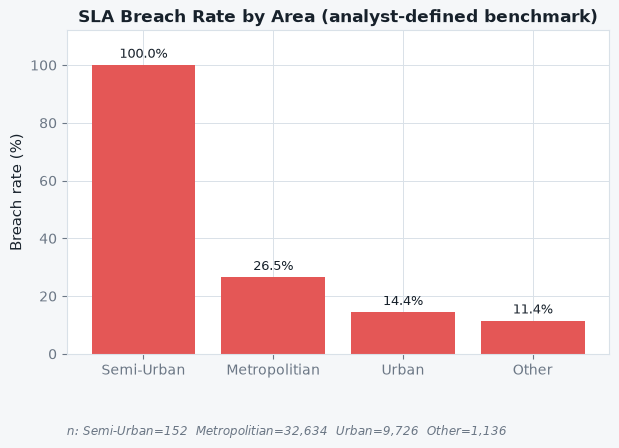

,n,breach_rate
Area,,
Semi-Urban,152,100.0000
Metropolitian,32634,26.5000
Urban,9726,14.3738
Other,1136,11.4437


In [3]:
by_area = (df.groupby("Area", observed=True)
             .agg(n=("sla_breach_flag", "count"), breach_rate=("sla_breach_flag", lambda s: 100 * s.mean()))
             .sort_values("breach_rate", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(by_area.index, by_area["breach_rate"], color=CORAL)
annotate_bars(ax, bars, fmt="{:.1f}%", offset=1.5)
ax.set_ylim(0, 112)
ax.set_title("SLA Breach Rate by Area (analyst-defined benchmark)")
ax.set_ylabel("Breach rate (%)")
sample_size_caption(ax, "n: " + "  ".join(f"{a}={int(n):,}" for a, n in by_area["n"].items()))
plt.show()
by_area


**Key observation:** Semi-Urban has a 100% breach rate — but on only n=152
deliveries (0.35% of the dataset). Metropolitian, the area carrying the bulk
of delivery volume (n=32,634, 74.8% of all deliveries), has a 26.50% breach
rate — elevated but well below Semi-Urban's. Urban (14.37%) and `Other`
(11.44%) are both lower.

**Rate ≠ volume:** Semi-Urban's rate is the highest on the smallest sample;
Metropolitian carries the largest volume of both deliveries and breaches
(see notebook 04 for the volume-concentration view).

**Limitation:** Semi-Urban's 100% figure is exact and reproducible, but a
152-row sample deserves caution before being treated as a stable,
generalizable rate — this caveat is carried through every notebook and
report that touches this figure.


## 3. SLA Breach Rate by Category

**Business question:** Does SLA breach rate vary materially by product
category?

**Analysis performed:** same breach-rate groupby, cut by `Category` instead
of `Area`.


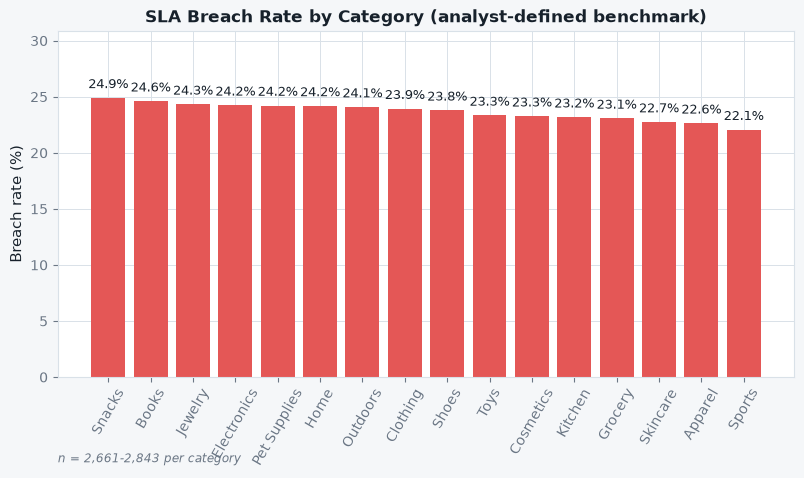

,n,breach_rate
Category,,
Snacks,2767,24.9006
Books,2817,24.6006
Jewelry,2796,24.3205
Electronics,2843,24.2350
Pet Supplies,2684,24.2176
Home,2680,24.1791
Outdoors,2741,24.0788
Clothing,2662,23.9294
Shoes,2661,23.7880


In [4]:
by_cat = (df.groupby("Category", observed=True)
            .agg(n=("sla_breach_flag", "count"), breach_rate=("sla_breach_flag", lambda s: 100 * s.mean()))
            .sort_values("breach_rate", ascending=False))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(by_cat.index, by_cat["breach_rate"], color=CORAL)
annotate_bars(ax, bars, fmt="{:.1f}%", offset=0.6)
ax.set_ylim(0, by_cat["breach_rate"].max() + 6)
ax.set_title("SLA Breach Rate by Category (analyst-defined benchmark)")
ax.set_ylabel("Breach rate (%)")
ax.tick_params(axis="x", rotation=60)
sample_size_caption(ax, f"n = {int(by_cat['n'].min()):,}-{int(by_cat['n'].max()):,} per category")
plt.show()
by_cat


**Key observation:** Because `sla_threshold_minutes` is defined as each
category's own P75 by construction, category-level breach rates cluster
close to 25% for most categories — this is a mechanical consequence of the
P75 definition, not an operational finding about any specific category.

**Limitation:** A P75-based threshold means roughly 1-in-4 deliveries breach
by construction in a typical category — the *area* cut (above) and
condition-based cuts (traffic/weather, notebook 04) are where genuine
performance variation shows up, not the category cut.

---

**Next:** [`04_root_cause_analysis.ipynb`](04_root_cause_analysis.ipynb) —
where SLA breach *volume* concentrates, and which conditions are associated
with it.
